In [1]:
!pip install qulacs qiskit-optimization networkx pandas scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.4/647.4 kB 10.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.31.254-py3-none-any.whl size=686240 sha256=856e8fe4d8f3d8b5b8791a61ad40afde81f4b7f6373e8f2d9599cb8a5d579f7a
  Stored in directory: /root/.cache/pip/wheels/9b/43/d7/d568c4f55eba9600a81c71914508b5f766ce122f560fa32cec
Successfully built docplex


In [2]:
import os
import zipfile
import urllib.request # More reliable than os.system("wget")

def setup_data():
    print("[1/3] Checking for dataset...")
    url = "https://snap.stanford.edu/data/ethereum-exchanges.zip"
    zip_path = "ethereum-exchanges.zip"
    
    if not os.path.exists(zip_path):
        print(f"      Downloading from {url}...")
        try:
            urllib.request.urlretrieve(url, zip_path)
            print("      Download Complete.")
        except Exception as e:
            print(f"      ERROR downloading: {e}")
            return

    print("[2/3] Extracting files...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(".")
        print("      Extraction Complete.")
    except Exception as e:
        print(f"      ERROR extracting: {e}")

    print("[3/3] Finalizing file names...")
    if os.path.exists("token_transfers.csv"):
        os.rename("token_transfers.csv", "token_transfers_full.csv")
        print("      File renamed to 'token_transfers_full.csv'")
    else:
        # Check if the file is already there from a previous run
        if os.path.exists("token_transfers_full.csv"):
            print("      'token_transfers_full.csv' already exists. Skipping.")
        else:
            print("      WARNING: 'token_transfers.csv' not found after extraction.")

# IMPORTANT: You must call the function for it to run!
setup_data()

[1/3] Checking for dataset...
      Download Complete.
[2/3] Extracting files...
      Extraction Complete.
[3/3] Finalizing file names...
      'token_transfers_full.csv' already exists. Skipping.


In [3]:
# !pip install qulacs qiskit-optimization networkx pandas scipy

import networkx as nx
import pandas as pd
import numpy as np
import warnings, time, json
from scipy.optimize import minimize
from collections import Counter

from qulacs import QuantumState, QuantumCircuit
from qulacs.gate import DiagonalMatrix
from qiskit_optimization import QuadraticProgram

warnings.filterwarnings("ignore")

# config
DATA_FILE = "token_transfers_full.csv"
LBL_FILE = "exchangeLabels.csv"
K_CYCLES = 18
P_DEPTH = 2
WEI_DIV = 10**18

def fmt_amt(num):
    if num == 0: return "$0"
    m = 0
    suf = ['', 'K', 'M', 'B', 'T', 'Q']
    while abs(num) >= 1000 and m < len(suf) - 1:
        m += 1; num /= 1000.0
    return f"${num:.2f}{suf[m]}"

def load_graph(data_path, lbl_path):
    print(f"[+] Loading {data_path}")
    try: df = pd.read_csv(data_path, nrows=300000)
    except: return nx.DiGraph(), {}

    df.columns = [c.lower() for c in df.columns]
    df.rename(columns={'from_address':'src', 'to_address':'dst', 'value':'amt'}, inplace=True)

    G = nx.DiGraph()
    for _, r in df.iterrows():
        try:
            u, v = str(r['src']).lower(), str(r['dst']).lower()
            w = float(r['amt']) / WEI_DIV
            if w > 0.001:
                if G.has_edge(u, v): G[u][v]['weight'] += w
                else: G.add_edge(u, v, weight=w)
        except: continue

    print("[+] Extracting SCCs")
    sccs = [c for c in nx.strongly_connected_components(G) if len(c) > 1]
    v_nodes = set().union(*sccs)
    g_scc = G.subgraph(v_nodes).copy()

    # cap core to top 800 active nodes
    vols = dict(g_scc.degree(weight='weight'))
    top_n = sorted(vols, key=vols.get, reverse=True)[:800]
    g_sub = g_scc.subgraph(top_n).copy()

    g_sub.remove_nodes_from(list(nx.isolates(g_sub)))
    n_map = {old: i for i, old in enumerate(g_sub.nodes())}
    g_final = nx.relabel_nodes(g_sub, n_map)

    print(f"[+] Graph ready: {g_final.number_of_nodes()}V, {g_final.number_of_edges()}E")
    return g_final, n_map

# main
if __name__ == "__main__":
    t0 = time.time()
    G, n_map = load_graph(DATA_FILE, LBL_FILE)
    inv_map = {v: k for k, v in n_map.items()}

    if G.number_of_nodes() == 0: exit()

    print("[1/4] Detecting cycles")
    try: all_cyc = list(nx.simple_cycles(G, length_bound=5))
    except: all_cyc = []

    cyc_data = []
    for c in all_cyc:
        if len(c) > 1:
            edg = list(zip(c, c[1:] + c[:1]))
            if all(G.has_edge(u, v) for u, v in edg):
                w = [G[u][v]['weight'] for u, v in edg]
                cyc_data.append((c, min(w), set(edg)))

    cyc_data.sort(key=lambda x: x[1], reverse=True)
    top_cyc = cyc_data[:K_CYCLES]
    c_nodes = [x[0] for x in top_cyc]
    c_sav = [x[1] for x in top_cyc]
    c_edg = [x[2] for x in top_cyc]

    if not c_nodes: exit()
    print(f"[+] Found {len(c_nodes)} top cycles")

    print("[2/4] Building QUBO")
    qp = QuadraticProgram()
    log_sav = [np.log1p(s) for s in c_sav]
    scale = max(log_sav)
    norm_sav = [s / scale for s in log_sav]

    for i in range(len(c_nodes)): qp.binary_var(f"c{i}")

    lin = {f"c{i}": -norm_sav[i] for i in range(len(c_nodes))}
    quad = {}

    for i in range(len(c_nodes)):
        for j in range(i + 1, len(c_nodes)):
            if c_edg[i].intersection(c_edg[j]):
                quad[(f"c{i}", f"c{j}")] = norm_sav[i] + norm_sav[j] + 0.1

    qp.minimize(linear=lin, quadratic=quad)
    ising, _ = qp.to_ising()
    n_q = ising.num_qubits

    print(f"[3/4] Running QAOA (p={P_DEPTH}, q={n_q})")
    n_states = 2**n_q
    h_diag = np.zeros(n_states)

    for pauli in ising:
        coef = pauli.coeffs[0].real
        lbl = pauli.paulis[0].to_label()
        z_idx = [i for i, ch in enumerate(reversed(lbl)) if ch == 'Z']

        if not z_idx:
            h_diag += coef
            continue

        mask = 0
        for idx in z_idx: mask |= (1 << idx)

        idx_arr = np.arange(n_states, dtype=np.int32)
        par = np.zeros(n_states)
        for i in range(n_q):
            if (mask >> i) & 1: par += (idx_arr >> i) & 1

        signs = np.where(par % 2 == 0, 1.0, -1.0)
        h_diag += coef * signs

    def qaoa_qc(params):
        st = QuantumState(n_q)
        st.set_zero_state()
        qc = QuantumCircuit(n_q)

        for i in range(n_q): qc.add_H_gate(i)

        for d in range(P_DEPTH):
            g, b = params[2*d], params[2*d + 1]
            diag = np.exp(-1j * g * h_diag)
            qc.add_gate(DiagonalMatrix(list(range(n_q)), diag))
            for i in range(n_q): qc.add_RX_gate(i, -2 * b)

        qc.update_quantum_state(st)
        return st

    def cost_fn(params):
        st = qaoa_qc(params)
        p = np.abs(st.get_vector())**2
        return np.sum(p * h_diag)

    np.random.seed(42)
    init_ang = np.random.uniform(0.1, 1.0, 2 * P_DEPTH)
    res = minimize(cost_fn, init_ang, method='COBYLA', options={'maxiter': 150})

    f_st = qaoa_qc(res.x)
    samps = f_st.sampling(100)
    best_i = Counter(samps).most_common(1)[0][0]
    bin_str = format(best_i, f'0{n_q}b')
    res_bits = [int(x) for x in reversed(bin_str)]

    print("[4/4] Extracting data")
    g_opt = G.copy()
    idx_lst = [i for i, v in enumerate(res_bits) if v == 1]

    tot_sav = 0
    log = []

    for i in idx_lst:
        amt = c_sav[i]
        tot_sav += amt
        path_orig = [inv_map.get(n, str(n)) for n in c_nodes[i]]

        log.append({
            "id": i, "amt": amt, "len": len(c_nodes[i]),
            "path_int": str(c_nodes[i]), "path_orig": str(path_orig)
        })

        for u, v in c_edg[i]:
            if g_opt.has_edge(u, v):
                g_opt[u][v]['weight'] -= amt
                if g_opt[u][v]['weight'] <= 1e-5: g_opt.remove_edge(u, v)

    vol_0 = sum(d['weight'] for u, v, d in G.edges(data=True))
    vol_1 = sum(d['weight'] for u, v, d in g_opt.edges(data=True))
    t_elap = time.time() - t0
    eff = (tot_sav / vol_0) * 100 if vol_0 > 0 else 0

    if log:
        pd.DataFrame(log).to_csv("qelc_log.csv", index=False)
        print("[+] Saved qelc_log.csv")

    smry = {
        "time_s": round(t_elap, 4), "debt_0": vol_0, "debt_1": vol_1,
        "cleared": tot_sav, "eff_pct": round(eff, 2), "n_cyc": len(idx_lst)
    }
    with open("qelc_smry.json", "w") as f:
        json.dump(smry, f, indent=4)
    print("[+] Saved qelc_smry.json")

    print("\n" + "="*40)
    print(" " * 12 + "QELC REPORT")
    print("="*40)
    print(f" Init Debt: {fmt_amt(vol_0)}")
    print(f" Fin Debt:  {fmt_amt(vol_1)}")
    print(f" Cleared:   {fmt_amt(tot_sav)}")
    print(f" Eff:       {eff:.2f}%")
    print(f" Cycles:    {len(idx_lst)}/{n_q}")
    print(f" Time:      {t_elap:.4f}s")
    print("="*40 + "\n")

[+] Loading token_transfers_full.csv
[+] Extracting SCCs
[+] Graph ready: 798V, 1865E
[1/4] Detecting cycles
[+] Found 18 top cycles
[2/4] Building QUBO
[3/4] Running QAOA (p=2, q=18)
[4/4] Extracting data
[+] Saved qelc_log.csv
[+] Saved qelc_smry.json

            QELC REPORT
 Init Debt: $23.01B
 Fin Debt:  $20.53B
 Cleared:   $813.82M
 Eff:       3.54%
 Cycles:    11/18
 Time:      34.5805s



In [4]:
import time, numpy as np
from scipy.optimize import minimize
from collections import Counter
from qiskit_optimization import QuadraticProgram
from qulacs import QuantumState, QuantumCircuit
from qulacs.gate import DiagonalMatrix

def run_k_cycles(k):
    print(f"\n--- QAOA Benchmark: {k} Qubits ---")
    t0 = time.time()
    cyc_data = []
    for c in all_cyc:
        if len(c) > 1:
            edg = list(zip(c, c[1:] + c[:1]))
            if all(G.has_edge(u, v) for u, v in edg):
                w = [G[u][v]['weight'] for u, v in edg]
                cyc_data.append((c, min(w), set(edg)))

    cyc_data.sort(key=lambda x: x[1], reverse=True)
    top_cyc = cyc_data[:k]
    c_nodes = [x[0] for x in top_cyc]
    c_sav = [x[1] for x in top_cyc]
    c_edg = [x[2] for x in top_cyc]
    qp = QuadraticProgram()
    log_sav = [np.log1p(s) for s in c_sav]
    scale = max(log_sav)
    norm_sav = [s / scale for s in log_sav]

    for i in range(len(c_nodes)): qp.binary_var(f"c{i}")
    lin = {f"c{i}": -norm_sav[i] for i in range(len(c_nodes))}
    quad = {}
    
    for i in range(len(c_nodes)):
        for j in range(i + 1, len(c_nodes)):
            if c_edg[i].intersection(c_edg[j]):
                quad[(f"c{i}", f"c{j}")] = norm_sav[i] + norm_sav[j] + 0.1

    qp.minimize(linear=lin, quadratic=quad)
    ising, _ = qp.to_ising()
    n_q = ising.num_qubits
    n_states = 2**n_q
    h_diag = np.zeros(n_states)
    for pauli in ising:
        coef = pauli.coeffs[0].real
        lbl = pauli.paulis[0].to_label()
        z_idx = [i for i, ch in enumerate(reversed(lbl)) if ch == 'Z']
        if not z_idx:
            h_diag += coef
            continue
        mask = sum([1 << idx for idx in z_idx])
        idx_arr = np.arange(n_states, dtype=np.int32)
        par = np.zeros(n_states)
        for i in range(n_q):
            if (mask >> i) & 1: par += (idx_arr >> i) & 1
        signs = np.where(par % 2 == 0, 1.0, -1.0)
        h_diag += coef * signs

    def qaoa_qc(params):
        st = QuantumState(n_q)
        st.set_zero_state()
        qc = QuantumCircuit(n_q)
        for i in range(n_q): qc.add_H_gate(i)
        for d in range(P_DEPTH):
            g, b = params[2*d], params[2*d + 1]
            diag = np.exp(-1j * g * h_diag)
            qc.add_gate(DiagonalMatrix(list(range(n_q)), diag))
            for i in range(n_q): qc.add_RX_gate(i, -2 * b)
        qc.update_quantum_state(st)
        return st

    def cost_fn(params):
        st = qaoa_qc(params)
        p = np.abs(st.get_vector())**2
        return np.sum(p * h_diag)

    np.random.seed(42)
    init_ang = np.random.uniform(0.1, 1.0, 2 * P_DEPTH)
    res = minimize(cost_fn, init_ang, method='COBYLA', options={'maxiter': 150})
    
    f_st = qaoa_qc(res.x)
    samps = f_st.sampling(100)
    best_i = Counter(samps).most_common(1)[0][0]
    bin_str = format(best_i, f'0{n_q}b')
    res_bits = [int(x) for x in reversed(bin_str)]
    g_opt = G.copy()
    idx_lst = [i for i, v in enumerate(res_bits) if v == 1]
    tot_sav = 0
    exec_det = []

    for i in idx_lst:
        amt = c_sav[i]
        tot_sav += amt
        path_orig = [inv_map.get(n, str(n)) for n in c_nodes[i]]
        exec_det.append(f"   - Cycle {i} | Cleared: {fmt_amt(amt)} | Hops: {len(c_nodes[i])} | Path: {path_orig}")
        for u, v in c_edg[i]:
            if g_opt.has_edge(u, v):
                g_opt[u][v]['weight'] -= amt
                if g_opt[u][v]['weight'] <= 1e-5: g_opt.remove_edge(u, v)

    vol_0 = sum(d['weight'] for u, v, d in G.edges(data=True))
    vol_1 = sum(d['weight'] for u, v, d in g_opt.edges(data=True))
    t_elap = time.time() - t0
    eff = (tot_sav / vol_0) * 100 if vol_0 > 0 else 0
    
    print(f" -> Done in {t_elap:.2f}s | Cleared: {fmt_amt(tot_sav)}")
    rep = (
        f"{'='*48}\n"
        f" TARGET QUBITS (CYCLES): {k}\n"
        f"{'='*48}\n"
        f" GRAPH TOPOLOGY:\n"
        f"  - Active Nodes: {G.number_of_nodes()}\n"
        f"  - Active Edges: {G.number_of_edges()}\n"
        f" FINANCIAL METRICS:\n"
        f"  - Init Debt: {fmt_amt(vol_0)}\n"
        f"  - Fin Debt:  {fmt_amt(vol_1)}\n"
        f"  - Cleared:   {fmt_amt(tot_sav)}\n"
        f"  - Eff:       {eff:.4f}%\n"
        f" EXECUTION METRICS:\n"
        f"  - Time:      {t_elap:.4f}s\n"
        f"  - Executed:  {len(idx_lst)}/{k}\n"
        f" CYCLE BREAKDOWN:\n"
        + ("\n".join(exec_det) if exec_det else "   - No cycles executed.") + "\n\n"
    )
    return rep
k_range = range(18, 23)
all_reps = ""

print(f"[+] Starting sweep for K in {list(k_range)}")
for k in k_range:
    all_reps += run_k_cycles(k)

fname = "qelc_scaling_benchmark.txt"
with open(fname, "w") as f:
    f.write("FUJITSU QELC - SCALING BENCHMARK\n")
    f.write(f"QAOA Depth: {P_DEPTH} | COBYLA | Qulacs\n\n")
    f.write(all_reps)

print(f"\n[+] Benchmark saved to '{fname}'")

[+] Starting sweep for K in [18, 19, 20, 21, 22]

--- QAOA Benchmark: 18 Qubits ---
 -> Done in 16.17s | Cleared: $683.88M

--- QAOA Benchmark: 19 Qubits ---
 -> Done in 35.42s | Cleared: $512.34M

--- QAOA Benchmark: 20 Qubits ---
 -> Done in 74.51s | Cleared: $659.71M

--- QAOA Benchmark: 21 Qubits ---
 -> Done in 180.35s | Cleared: $957.03M

--- QAOA Benchmark: 22 Qubits ---
 -> Done in 353.06s | Cleared: $810.81M

[+] Benchmark saved to 'qelc_scaling_benchmark.txt'


In [5]:

import networkx as nx
import pandas as pd
import numpy as np
import warnings, time, json
from scipy.optimize import minimize
from collections import Counter

from qulacs import QuantumState, QuantumCircuit
from qulacs.gate import DiagonalMatrix
from qiskit_optimization import QuadraticProgram

warnings.filterwarnings("ignore")

# config
DATA_FILE = "token_transfers_full.csv"
LBL_FILE = "exchangeLabels.csv"
K_CYCLES = 19       # Optimal batch size
P_DEPTH = 2         # Optimal QAOA depth
WEI_DIV = 10**18
MAX_ITERS = 30      # Sufficient limit for graph exhaustion

def fmt_amt(num):
    if num == 0: return "$0"
    m = 0
    suf = ['', 'K', 'M', 'B', 'T', 'Q']
    while abs(num) >= 1000 and m < len(suf) - 1:
        m += 1; num /= 1000.0
    return f"${num:.2f}{suf[m]}"

def load_graph(data_path, lbl_path):
    print(f"[+] Loading {data_path}")
    try: df = pd.read_csv(data_path, nrows=300000)
    except: return nx.DiGraph(), {}

    df.columns = [c.lower() for c in df.columns]
    df.rename(columns={'from_address':'src', 'to_address':'dst', 'value':'amt'}, inplace=True)

    G = nx.DiGraph()
    for _, r in df.iterrows():
        try:
            u, v = str(r['src']).lower(), str(r['dst']).lower()
            w = float(r['amt']) / WEI_DIV
            if w > 0.001:
                if G.has_edge(u, v): G[u][v]['weight'] += w
                else: G.add_edge(u, v, weight=w)
        except: continue

    sccs = [c for c in nx.strongly_connected_components(G) if len(c) > 1]
    v_nodes = set().union(*sccs)
    g_scc = G.subgraph(v_nodes).copy()

    vols = dict(g_scc.degree(weight='weight'))
    top_n = sorted(vols, key=vols.get, reverse=True)[:800]
    g_sub = g_scc.subgraph(top_n).copy()

    g_sub.remove_nodes_from(list(nx.isolates(g_sub)))
    n_map = {old: i for i, old in enumerate(g_sub.nodes())}
    g_final = nx.relabel_nodes(g_sub, n_map)

    print(f"[+] Graph ready: {g_final.number_of_nodes()}V, {g_final.number_of_edges()}E")
    return g_final, n_map

if __name__ == "__main__":
    t0_global = time.time()
    G, n_map = load_graph(DATA_FILE, LBL_FILE)
    inv_map = {v: k for k, v in n_map.items()}

    if G.number_of_nodes() == 0: exit()

    vol_initial = sum(d['weight'] for u, v, d in G.edges(data=True))
    tot_sav_global = 0
    tot_cyc_global = 0
    master_log = []

    print(f"\n[+] Starting Iterative Peeling Engine | Max Iters: {MAX_ITERS} | Batch: {K_CYCLES}")
    print(f"[+] Initial Debt: {fmt_amt(vol_initial)}\n")

    for iter_idx in range(1, MAX_ITERS + 1):
        print(f"--- ITERATION {iter_idx} ---")
        try: all_cyc = list(nx.simple_cycles(G, length_bound=5))
        except: all_cyc = []

        cyc_data = []
        for c in all_cyc:
            if len(c) > 1:
                edg = list(zip(c, c[1:] + c[:1]))
                if all(G.has_edge(u, v) for u, v in edg):
                    w = [G[u][v]['weight'] for u, v in edg]
                    cyc_data.append((c, min(w), set(edg)))

        cyc_data.sort(key=lambda x: x[1], reverse=True)
        top_cyc = cyc_data[:K_CYCLES]
        
        if not top_cyc:
            print("[!] No more cycles found. Gridlock fully cleared.")
            break
            
        c_nodes = [x[0] for x in top_cyc]
        c_sav = [x[1] for x in top_cyc]
        c_edg = [x[2] for x in top_cyc]
        qp = QuadraticProgram()
        log_sav = [np.log1p(s) for s in c_sav]
        scale = max(log_sav)
        norm_sav = [s / scale for s in log_sav]

        for i in range(len(c_nodes)): qp.binary_var(f"c{i}")
        lin = {f"c{i}": -norm_sav[i] for i in range(len(c_nodes))}
        quad = {}

        for i in range(len(c_nodes)):
            for j in range(i + 1, len(c_nodes)):
                if c_edg[i].intersection(c_edg[j]):
                    quad[(f"c{i}", f"c{j}")] = norm_sav[i] + norm_sav[j] + 0.1

        qp.minimize(linear=lin, quadratic=quad)
        ising, _ = qp.to_ising()
        n_q = ising.num_qubits
        n_states = 2**n_q
        h_diag = np.zeros(n_states)

        for pauli in ising:
            coef = pauli.coeffs[0].real
            lbl = pauli.paulis[0].to_label()
            z_idx = [i for i, ch in enumerate(reversed(lbl)) if ch == 'Z']
            if not z_idx:
                h_diag += coef
                continue
            mask = sum([1 << idx for idx in z_idx])
            idx_arr = np.arange(n_states, dtype=np.int32)
            par = np.zeros(n_states)
            for i in range(n_q):
                if (mask >> i) & 1: par += (idx_arr >> i) & 1
            signs = np.where(par % 2 == 0, 1.0, -1.0)
            h_diag += coef * signs

        def qaoa_qc(params):
            st = QuantumState(n_q)
            st.set_zero_state()
            qc = QuantumCircuit(n_q)
            for i in range(n_q): qc.add_H_gate(i)
            for d in range(P_DEPTH):
                g, b = params[2*d], params[2*d + 1]
                diag = np.exp(-1j * g * h_diag)
                qc.add_gate(DiagonalMatrix(list(range(n_q)), diag))
                for i in range(n_q): qc.add_RX_gate(i, -2 * b)
            qc.update_quantum_state(st)
            return st

        def cost_fn(params):
            st = qaoa_qc(params)
            p = np.abs(st.get_vector())**2
            return np.sum(p * h_diag)
        tot_sav_iter = 0
        idx_lst = []
        
        for attempt in range(3):
            np.random.seed(42 + iter_idx * 10 + attempt) # vastly different seed
            init_ang = np.random.uniform(0.1, 1.0, 2 * P_DEPTH)
            res = minimize(cost_fn, init_ang, method='COBYLA', options={'maxiter': 150})

            f_st = qaoa_qc(res.x)
            samps = f_st.sampling(100)
            best_i = Counter(samps).most_common(1)[0][0]
            bin_str = format(best_i, f'0{n_q}b')
            res_bits = [int(x) for x in reversed(bin_str)]
            
            idx_lst = [i for i, v in enumerate(res_bits) if v == 1]
            tot_sav_iter = sum(c_sav[i] for i in idx_lst)
            
            if tot_sav_iter > 0:
                break
            else:
                print(f" [!] Optimizer trapped. Retrying with new seed (Attempt {attempt+1}/3)...")

        if tot_sav_iter == 0:
            print(" [!] Gridlock too dense. Breaking the #1 toxic cycle to force new topology...")
            u, v = list(c_edg[0])[0]
            if G.has_edge(u, v): G.remove_edge(u, v)
            continue

        idx_lst_sorted = sorted(idx_lst, key=lambda i: c_sav[i], reverse=True)
        valid_cycles_cleared = 0
        actual_savings_iter = 0

        for i in idx_lst_sorted:
            amt = c_sav[i]
            
            can_execute = True
            for u, v in c_edg[i]:
                if not G.has_edge(u, v) or G[u][v]['weight'] < amt - 1e-5:
                    can_execute = False
                    break
                    
            if not can_execute:
                continue
                
            valid_cycles_cleared += 1
            actual_savings_iter += amt
            path_orig = [inv_map.get(n, str(n)) for n in c_nodes[i]]

            master_log.append({
                "iteration": iter_idx, "cycle_id": i, "amt": amt, 
                "len": len(c_nodes[i]), "path_int": str(c_nodes[i]), "path_orig": str(path_orig)
            })

            for u, v in c_edg[i]:
                G[u][v]['weight'] -= amt
                if G[u][v]['weight'] <= 1e-5: G.remove_edge(u, v)

        tot_sav_global += actual_savings_iter
        tot_cyc_global += valid_cycles_cleared
        vol_curr = sum(d['weight'] for u, v, d in G.edges(data=True))
        
        print(f" -> Cleared {valid_cycles_cleared} valid cycles | Vol: {fmt_amt(actual_savings_iter)} | New Debt: {fmt_amt(vol_curr)}")

        
    vol_final = sum(d['weight'] for u, v, d in G.edges(data=True))
    t_elap_global = time.time() - t0_global
    eff_global = (tot_sav_global / vol_initial) * 100 if vol_initial > 0 else 0

    if master_log:
        pd.DataFrame(master_log).to_csv("qelc_iterative_log.csv", index=False)

    print("\n" + "="*45)
    print(" " * 8 + "FINAL ITERATIVE REPORT")
    print("="*45)
    print(f" Total Iters Run:   {iter_idx}")
    print(f" Init Sys Debt:     {fmt_amt(vol_initial)}")
    print(f" Final Sys Debt:    {fmt_amt(vol_final)}")
    print(f" Total Cleared:     {fmt_amt(tot_sav_global)}")
    print(f" Netting Eff:       {eff_global:.2f}%")
    print(f" Total Exec Cyc:    {tot_cyc_global} cycles")
    print(f" Total Exec Time:   {t_elap_global:.2f}s")
    print("="*45 + "\n")

[+] Loading token_transfers_full.csv
[+] Graph ready: 798V, 1865E

[+] Starting Iterative Peeling Engine | Max Iters: 30 | Batch: 19
[+] Initial Debt: $23.01B

--- ITERATION 1 ---
 -> Cleared 3 valid cycles | Vol: $221.00M | New Debt: $21.97B
--- ITERATION 2 ---
 -> Cleared 1 valid cycles | Vol: $54.12M | New Debt: $21.70B
--- ITERATION 3 ---
 -> Cleared 2 valid cycles | Vol: $142.47M | New Debt: $21.19B
--- ITERATION 4 ---
 -> Cleared 8 valid cycles | Vol: $461.80M | New Debt: $19.60B
--- ITERATION 5 ---
 -> Cleared 2 valid cycles | Vol: $84.86M | New Debt: $19.18B
--- ITERATION 6 ---
 -> Cleared 6 valid cycles | Vol: $248.30M | New Debt: $18.27B
--- ITERATION 7 ---
 -> Cleared 2 valid cycles | Vol: $70.42M | New Debt: $18.02B
--- ITERATION 8 ---
 -> Cleared 3 valid cycles | Vol: $95.44M | New Debt: $17.54B
--- ITERATION 9 ---
 -> Cleared 3 valid cycles | Vol: $89.59M | New Debt: $17.19B
--- ITERATION 10 ---
 -> Cleared 1 valid cycles | Vol: $27.79M | New Debt: $17.10B
--- ITERATION 1

In [6]:
import pandas as pd
import networkx as nx
import ast

print("=============================================")
print("  QELC ENTERPRISE AUDITOR - VERIFYING LOGS   ")
print("=============================================")

DATA_FILE = "token_transfers_full.csv"
LOG_FILE = "qelc_iterative_log.csv"
WEI_DIV = 10**18

print("[1/3] Rebuilding original untouched ledger...")
df_transfers = pd.read_csv(DATA_FILE, nrows=300000)
df_transfers.columns = [c.lower() for c in df_transfers.columns]
df_transfers.rename(columns={'from_address':'src', 'to_address':'dst', 'value':'amt'}, inplace=True)

G_audit = nx.DiGraph()
for _, r in df_transfers.iterrows():
    try:
        u, v = str(r['src']).lower(), str(r['dst']).lower()
        w = float(r['amt']) / WEI_DIV
        if w > 0.001:
            if G_audit.has_edge(u, v): G_audit[u][v]['weight'] += w
            else: G_audit.add_edge(u, v, weight=w)
    except: continue

print("[2/3] Loading quantum execution logs...")
try:
    df_log = pd.read_csv(LOG_FILE)
except FileNotFoundError:
    print("[FAIL] 'qelc_iterative_log.csv' not found. Run the peeling engine first.")
    exit()
print(f"[3/3] Auditing {len(df_log)} executed cycles for Conservation of Flow...")
audit_passed = True

for idx, row in df_log.iterrows():
    amt = float(row['amt'])
    path = ast.literal_eval(row['path_orig']) 
    
    edges = list(zip(path, path[1:] + path[:1]))
    
    for u, v in edges:
        if not G_audit.has_edge(u, v):
            print(f"\n[FAIL] Phantom Edge! {u} -> {v} does not exist in Iteration {row['iteration']}.")
            audit_passed = False
            break
        
        if G_audit[u][v]['weight'] < amt - 1e-5:
            print(f"\n[FAIL] Overdraft! {u} -> {v} only has {G_audit[u][v]['weight']} but engine cleared {amt}.")
            audit_passed = False
            break
            
        G_audit[u][v]['weight'] -= amt

    if not audit_passed: break

if audit_passed:
    print("\n[SUCCESS] AUDIT PASSED! 100% Conservation of Flow verified.")
    print("All cycles are perfectly executable via atomic smart contracts.")
else:
    print("\n[!] AUDIT FAILED. Graph integrity was violated.")

  QELC ENTERPRISE AUDITOR - VERIFYING LOGS   
[1/3] Rebuilding original untouched ledger...
[2/3] Loading quantum execution logs...
[3/3] Auditing 72 executed cycles for Conservation of Flow...

[SUCCESS] AUDIT PASSED! 100% Conservation of Flow verified.
All cycles are perfectly executable via atomic smart contracts.


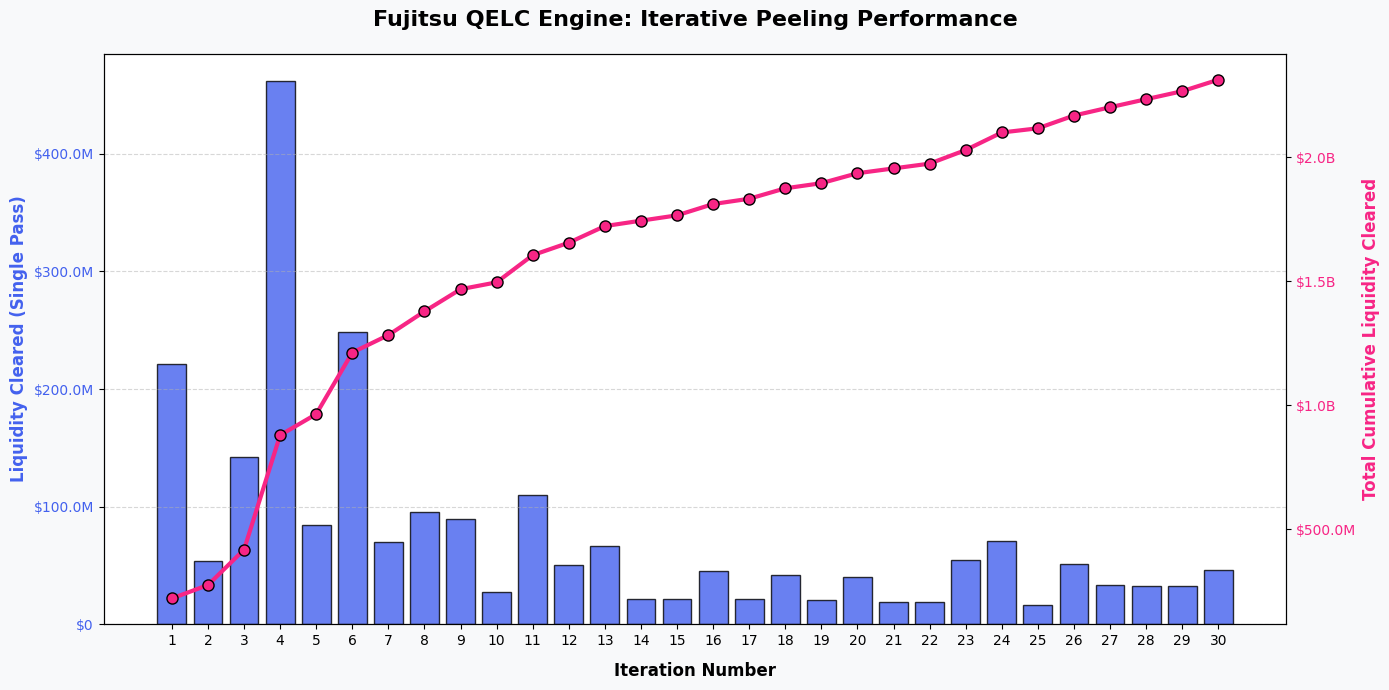

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def human_format(x, pos):
    if x == 0: return "$0"
    m = 0
    suf = ['', 'K', 'M', 'B', 'T']
    while abs(x) >= 1000 and m < len(suf) - 1:
        m += 1; x /= 1000.0
    return f"${x:.1f}{suf[m]}"

def plot_qelc_results(log_file="qelc_iterative_log.csv"):
    try:
        df_log = pd.read_csv(log_file)
    except FileNotFoundError:
        print("Log file not found. Ensure the QELC engine has finished running.")
        return

    iter_stats = df_log.groupby('iteration')['amt'].sum().reset_index()
    iter_stats['cumulative'] = iter_stats['amt'].cumsum()

    fig, ax1 = plt.subplots(figsize=(14, 7), facecolor='#f8f9fa')
    ax1.set_facecolor('#ffffff')

    ax1.bar(iter_stats['iteration'], iter_stats['amt'], color='#4361ee', alpha=0.8, edgecolor='black', linewidth=1)
    ax1.set_xlabel('Iteration Number', fontsize=12, fontweight='bold', labelpad=10)
    ax1.set_ylabel('Liquidity Cleared (Single Pass)', color='#4361ee', fontsize=12, fontweight='bold')
    ax1.yaxis.set_major_formatter(FuncFormatter(human_format))
    ax1.tick_params(axis='y', labelcolor='#4361ee')
    ax1.set_xticks(iter_stats['iteration'])
    
    ax2 = ax1.twinx()
    ax2.plot(iter_stats['iteration'], iter_stats['cumulative'], color='#f72585', marker='o', 
             linewidth=3, markersize=8, markeredgecolor='black', label='Cumulative Cleared')
    ax2.set_ylabel('Total Cumulative Liquidity Cleared', color='#f72585', fontsize=12, fontweight='bold')
    ax2.yaxis.set_major_formatter(FuncFormatter(human_format))
    ax2.tick_params(axis='y', labelcolor='#f72585')

    plt.title('Fujitsu QELC Engine: Iterative Peeling Performance', fontsize=16, fontweight='bold', pad=20)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    fig.tight_layout()
    plt.show()

plot_qelc_results()